見つかったファイル: ['px_0.0_Lx_10_MPI_results.npz', 'px_0.0_Lx_12_MPI_results.npz']
[0.5   0.525 0.55  0.575 0.6   0.625 0.65  0.675 0.7   0.725 0.75  0.775
 0.8   0.825 0.85  0.875 0.9   0.925 0.95  0.975 1.   ]
[0.5 0.6 0.7 0.8 0.9 1. ]


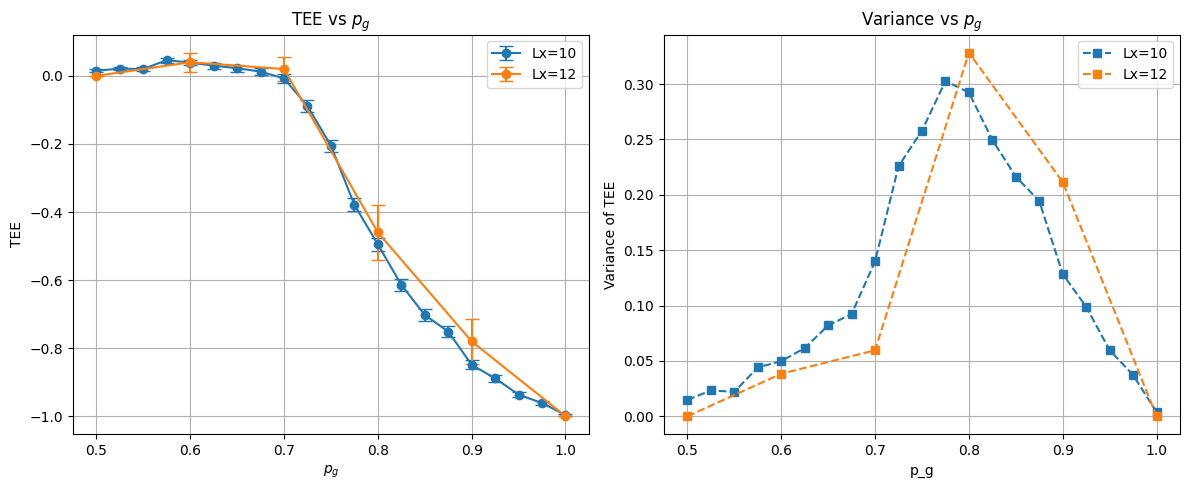

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import glob


cmap = plt.colormaps['gnuplot']
# npzファイルのパターン。Lxの値が変わる場合にマッチさせる
#files = glob.glob("Lx_*_MPI_results.npz")
files = glob.glob("px_0.0_Lx_*_MPI_results.npz")
print("見つかったファイル:", files)

fig, ax = plt.subplots(1, 2, figsize=(12, 5))

for file in files:
    data = np.load(file)
    # ファイル名からLxの値を抽出 (例: Lx_12_MPI_results.npz → 12)
    Lx_str = file.split("_")[3]  # '12'の部分
    Lx = int(Lx_str)
    #Lx_str = file.split("_")[1]  # '12'の部分
    #Lx = Lx_str

    pg = data['pg']
    TEE_ave = data['TEE_ave']
    TEE_err = data['TEE_err']
    TEE_var = data['TEE_var']

    data.close()

    label = f"Lx={Lx}"
    # 左グラフ：TEEの平均値＋誤差バー
    ax[0].errorbar(pg, TEE_ave, yerr=TEE_err,fmt='o-', capsize=5, label=label)
    # 右グラフ：TEEの分散
    ax[1].plot(pg, TEE_var, 's--', label=label)
    print(pg)

ax[0].set_xlabel('$p_g$')
ax[0].set_ylabel('TEE')
ax[0].set_title('TEE vs $p_g$')
ax[0].grid(True)
ax[0].legend()

ax[1].set_xlabel('p_g')
ax[1].set_ylabel('Variance of TEE')
ax[1].set_title('Variance vs $p_g$')
ax[1].grid(True)
ax[1].legend()

plt.tight_layout()
plt.show()


In [11]:
import numpy as np

data = np.load("px_0.0_Lx_16_MPI_results.npz")
print(data['pg'])
print(data['TEE_ave'])
print(data['TEE_err'])
print(data['TEE_var'])
data.close()

[0.5  0.55 0.6  0.65 0.7  0.75 0.8  0.85 0.9  0.95 1.  ]
[ 0.04  0.02  0.04 -0.06 -0.02 -0.28 -0.22 -0.7  -0.88 -0.98 -1.  ]
[0.02799417 0.02       0.02799417 0.03392669 0.04508495 0.07580857
 0.07165678 0.06546537 0.05451081 0.02       0.        ]
[0.0384 0.0196 0.0384 0.0564 0.0996 0.2816 0.2516 0.21   0.1456 0.0196
 0.    ]


In [8]:
import numpy as np

data = np.load("px_0.0_Lx_12_MPI_results.npz")
print(data.files)  # 保存されているキーの一覧を表示
data.close()

['pg', 'TEE_ave', 'TEE_err', 'TEE_var']


見つかったファイル: ['px_0.0_Lx_14_MPI_results.npz', 'px_0.0_Lx_10_MPI_results.npz', 'px_0.0_Lx_16_MPI_results.npz', 'px_0.0_Lx_12_MPI_results.npz']
px_0.0_Lx_10_MPI_results.npz: pg = [0.5  0.55 0.6  0.65 0.7  0.75 0.8  0.85 0.9  0.95 1.  ]
px_0.0_Lx_12_MPI_results.npz: pg = [0.5  0.55 0.6  0.65 0.7  0.75 0.8  0.85 0.9  0.95 1.  ]
px_0.0_Lx_14_MPI_results.npz: pg = [0.5  0.55 0.6  0.65 0.7  0.75 0.8  0.85 0.9  0.95 1.  ]
px_0.0_Lx_16_MPI_results.npz: pg = [0.5  0.55 0.6  0.65 0.7  0.75 0.8  0.85 0.9  0.95 1.  ]


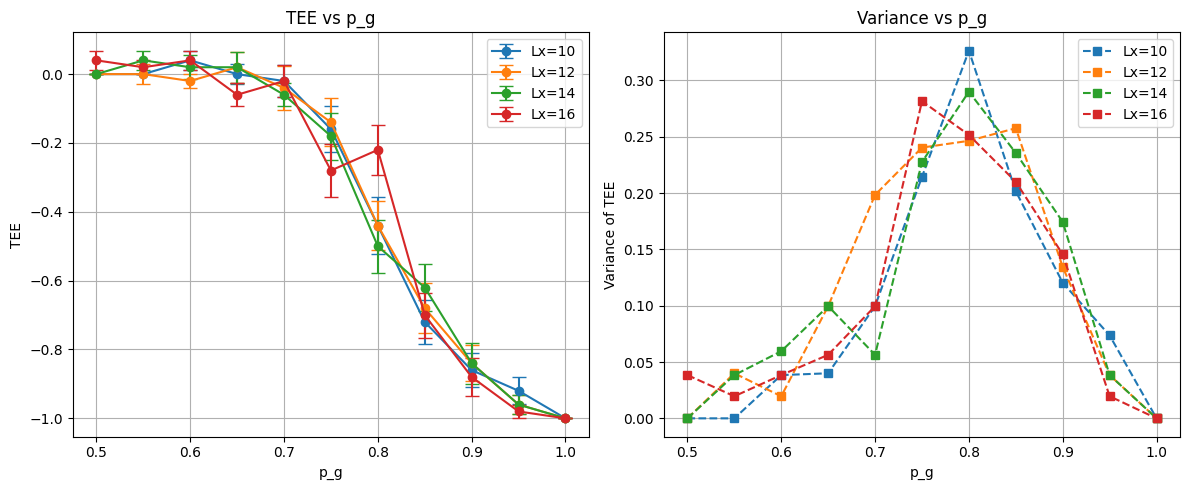

In [13]:
import numpy as np
import matplotlib.pyplot as plt
import glob
import re

cmap = plt.colormaps['gnuplot']

# ファイル読み込み（Lxの数字を含むもの）
files = glob.glob("px_0.0_Lx_*_MPI_results.npz")
print("見つかったファイル:", files)

# --- Lxの数値でソート ---
lx_file_pairs = []
for file in files:
    match = re.search(r'Lx_(\d+)', file)
    if match:
        Lx = int(match.group(1))
        lx_file_pairs.append((Lx, file))
    else:
        print(f"Lxの抽出失敗: {file}")

# 数値順に並べ替え（10, 12, 14, 16...）
lx_file_pairs.sort(key=lambda x: x[0])

# プロット用
fig, ax = plt.subplots(1, 2, figsize=(12, 5))

for Lx, file in lx_file_pairs:
    with np.load(file) as data:
        pg = data['pg']
        TEE_ave = data['TEE_ave']
        TEE_err = data['TEE_err']
        TEE_var = data['TEE_var']

    label = f"Lx={Lx}"
    # 左グラフ：TEEの平均値＋誤差バー
    ax[0].errorbar(pg, TEE_ave, yerr=TEE_err, fmt='o-', capsize=5, label=label)
    # 右グラフ：TEEの分散
    ax[1].plot(pg, TEE_var, 's--', label=label)
    print(f"{file}: pg = {pg}")

# 描画設定
ax[0].set_xlabel('p_g')
ax[0].set_ylabel('TEE')
ax[0].set_title('TEE vs p_g')
ax[0].grid(True)
ax[0].legend()

ax[1].set_xlabel('p_g')
ax[1].set_ylabel('Variance of TEE')
ax[1].set_title('Variance vs p_g')
ax[1].grid(True)
ax[1].legend()

plt.tight_layout()
plt.show()
